# NLP Extract Immobilier — Notebook final complet prêt à exécuter

## Objectif de la tâche
**Automatiser l’extraction des informations importantes à partir des descriptions immobilières afin de structurer les données et améliorer la recherche des biens.**

Ce notebook est dédié uniquement au **NLP Extract**. Il contient :

- chargement robuste du gros dataset CSV,
- correction d'encodage avec `ftfy`,
- création du texte NLP `title + description + type + transaction + zone`,
- génération des labels NLP avec règles métier,
- support d’un fichier `manual_gold.csv` pour annotation humaine,
- comparaison de plusieurs architectures :
  - Rule-based Lexicon,
  - TF-IDF + Logistic Regression,
  - TextCNN,
  - BiLSTM + Attention,
  - Transformer Encoder multilingual XLM-RoBERTa,
  - Sentence-BERT pour recherche sémantique,
  - FLAN-T5 pour démonstration JSON générative,
- métriques : Precision, Recall, F1 micro, F1 macro, Hamming Loss, Jaccard,
- génération JSON structuré,
- recherche améliorée,
- exports pour la présentation.

## 0. Installation
Active GPU dans Colab : `Runtime → Change runtime type → GPU`.

In [1]:
!pip -q install ftfy transformers accelerate sentence-transformers scikit-learn tensorflow matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00


## 1. Configuration globale

Pour le dataset complet, garde `MAX_ROWS = None`.  
Pour éviter que Colab coupe avec XLM-RoBERTa, `MAX_TRANSFORMER_ROWS = 12000` par défaut.

In [2]:
import os, re, csv, json, glob, random, warnings, unicodedata, shutil, gc
from pathlib import Path

# Important pour éviter la fragmentation mémoire GPU entre TensorFlow et PyTorch
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Dataset
DATA_PATH = "/content/tunisia_realestate_cleaned.csv"
FORCE_REUPLOAD = False
MAX_ROWS = None   # None = utiliser tout le dataset

# Modèles
# Version Colab stable et légère : DistilBERT multilingual.
# Si tu as Colab Pro / A100, tu peux remplacer par "xlm-roberta-base".
TRANSFORMER_MODEL_NAME = "distilbert-base-multilingual-cased"
SENTENCE_BERT_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
T5_MODEL_NAME = "google/flan-t5-small"

# Exécution des modèles
RUN_RULE_BASED = True
RUN_TFIDF = True
RUN_TEXTCNN = True
RUN_BILSTM_ATTENTION = True
RUN_TRANSFORMER = True
RUN_SEMANTIC_SEARCH = True
RUN_T5_JSON_GENERATION = True

# Paramètres généraux
TEST_SIZE = 0.20
VAL_SIZE = 0.10
EPOCHS_DEEP = 3
EPOCHS_TRANSFORMER = 2
BATCH_SIZE_DEEP = 64
BATCH_SIZE_TRANSFORMER = 2   # petit batch pour éviter CUDA OOM
TRANSFORMER_GRADIENT_ACCUMULATION = 4
TRANSFORMER_MAX_LENGTH = 128
MAX_WORDS = 40000
MAX_LEN = 180

# Pour éviter OOM : on entraîne le Transformer sur un sous-échantillon.
# Tu peux augmenter progressivement : 2000 → 5000 → 12000.
MAX_TRANSFORMER_ROWS = 2000
TRANSFORMER_CPU_FALLBACK = True
RELEASE_TF_GPU_BEFORE_TRANSFORMER = True

ARTIFACT_DIR = Path("/content/nlp_extract_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuration chargée")
print("Artefacts:", ARTIFACT_DIR)
print("Transformer:", TRANSFORMER_MODEL_NAME)
print("MAX_TRANSFORMER_ROWS:", MAX_TRANSFORMER_ROWS)
print("Batch transformer:", BATCH_SIZE_TRANSFORMER, "| gradient accumulation:", TRANSFORMER_GRADIENT_ACCUMULATION)


✅ Configuration chargée
Artefacts: /content/nlp_extract_artifacts
Transformer: distilbert-base-multilingual-cased
MAX_TRANSFORMER_ROWS: 2000
Batch transformer: 2 | gradient accumulation: 4


## 2. Chargement robuste du dataset

Cette cellule corrige les problèmes courants : fichier CSV mal fermé, guillemets cassés, encodage incorrect, séparateur différent. Elle choisit automatiquement la lecture qui récupère le plus de lignes.

In [3]:
from google.colab import files


def count_physical_lines(path):
    try:
        with open(path, "rb") as f:
            return sum(1 for _ in f)
    except Exception:
        return None


def choose_csv_file():
    global DATA_PATH
    if FORCE_REUPLOAD:
        print("➡️ Upload demandé")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("Aucun fichier uploadé")
        DATA_PATH = "/content/" + list(uploaded.keys())[0]
        return DATA_PATH

    candidates = []
    if DATA_PATH and os.path.exists(DATA_PATH):
        candidates.append(DATA_PATH)
    candidates.extend(glob.glob("/content/*.csv"))
    candidates = sorted(set(candidates), key=lambda p: os.path.getsize(p) if os.path.exists(p) else 0, reverse=True)
    if candidates:
        DATA_PATH = candidates[0]
        return DATA_PATH

    print("⚠️ Aucun CSV trouvé. Upload maintenant.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("Aucun fichier uploadé")
    DATA_PATH = "/content/" + list(uploaded.keys())[0]
    return DATA_PATH


def manual_repair_read_csv(path, sep=","):
    print("🛠️ Fallback manuel : réparation ligne par ligne")
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        header_line = f.readline().rstrip("\n\r")

    if header_line.count(";") > header_line.count(","):
        sep = ";"

    columns = [c.strip().strip('"') for c in header_line.split(sep)]
    n_cols = len(columns)
    desc_candidates = [i for i, c in enumerate(columns) if "desc" in c.lower()]
    desc_idx = desc_candidates[0] if desc_candidates else min(1, n_cols - 1)

    rows, bad = [], 0
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        next(f, None)
        for line in f:
            line = line.rstrip("\n\r")
            if not line.strip():
                continue
            line = line.replace('"', "'")
            parts = line.split(sep)
            if len(parts) == n_cols:
                rows.append(parts)
            elif len(parts) > n_cols:
                extra = len(parts) - n_cols
                merged = parts[:desc_idx] + [sep.join(parts[desc_idx:desc_idx + extra + 1])] + parts[desc_idx + extra + 1:]
                if len(merged) == n_cols:
                    rows.append(merged)
                else:
                    bad += 1
            else:
                rows.append((parts + [""] * (n_cols - len(parts)))[:n_cols])

    df_manual = pd.DataFrame(rows, columns=columns)
    print(f"✅ Fallback manuel terminé | lignes={len(df_manual)} | ignorées={bad}")
    return df_manual


def robust_read_csv(path):
    physical_lines = count_physical_lines(path)
    print("✅ Fichier utilisé:", path)
    print("📌 Taille MB:", round(os.path.getsize(path) / 1024 / 1024, 2))
    print("📌 Lignes physiques:", physical_lines)

    attempts = [
        {"encoding": "utf-8", "sep": None, "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "utf-8-sig", "sep": None, "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "latin1", "sep": None, "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "utf-8", "sep": ",", "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "latin1", "sep": ",", "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "utf-8", "sep": ";", "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "latin1", "sep": ";", "engine": "python", "on_bad_lines": "skip"},
        {"encoding": "utf-8", "sep": ",", "engine": "python", "on_bad_lines": "skip", "quoting": csv.QUOTE_NONE},
        {"encoding": "latin1", "sep": ",", "engine": "python", "on_bad_lines": "skip", "quoting": csv.QUOTE_NONE},
    ]

    best_df, best_score = None, -1
    for i, params in enumerate(attempts, 1):
        try:
            print(f"🔄 Tentative {i}: {params}")
            tmp = pd.read_csv(path, **params)
            print("   -> shape:", tmp.shape)
            score = tmp.shape[0] * max(tmp.shape[1], 1)
            if tmp.shape[1] > 1 and score > best_score:
                best_df, best_score = tmp, score
        except Exception as e:
            print("   ❌", type(e).__name__, str(e)[:120])

    if physical_lines and (best_df is None or len(best_df) < physical_lines * 0.75):
        try:
            manual = manual_repair_read_csv(path)
            if best_df is None or len(manual) > len(best_df):
                best_df = manual
        except Exception as e:
            print("❌ Fallback manuel échoué:", e)

    if best_df is None:
        raise RuntimeError("Impossible de lire le dataset")

    print("✅ Lecture finale:", best_df.shape)
    if physical_lines:
        ratio = len(best_df) / max(physical_lines - 1, 1)
        print(f"📌 Ratio lignes récupérées: {ratio:.2%}")
    return best_df

DATA_PATH = choose_csv_file()
df_raw = robust_read_csv(DATA_PATH)

if MAX_ROWS is not None and len(df_raw) > MAX_ROWS:
    df_raw = df_raw.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)
    print("⚠️ MAX_ROWS appliqué:", MAX_ROWS)

print("✅ Dataset chargé")
print("Shape:", df_raw.shape)
display(df_raw.head())
print("Colonnes:", list(df_raw.columns))

⚠️ Aucun CSV trouvé. Upload maintenant.


Saving tunisia_realestate_cleaned.csv to tunisia_realestate_cleaned.csv
✅ Fichier utilisé: /content/tunisia_realestate_cleaned.csv
📌 Taille MB: 14.0
📌 Lignes physiques: 61379
🔄 Tentative 1: {'encoding': 'utf-8', 'sep': None, 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (4543, 48)
🔄 Tentative 2: {'encoding': 'utf-8-sig', 'sep': None, 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (4543, 48)
🔄 Tentative 3: {'encoding': 'latin1', 'sep': None, 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (4543, 48)
🔄 Tentative 4: {'encoding': 'utf-8', 'sep': ',', 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (4543, 48)
🔄 Tentative 5: {'encoding': 'latin1', 'sep': ',', 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (4543, 48)
🔄 Tentative 6: {'encoding': 'utf-8', 'sep': ';', 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (50876, 1)
🔄 Tentative 7: {'encoding': 'latin1', 'sep': ';', 'engine': 'python', 'on_bad_lines': 'skip'}
   -> shape: (50880,

,ï»¿adresse,annee_constr,bus,caracteristiques,contrat,date_publication,description,ecole,etage,gouvernerat,...,pub_year,pub_month,desc_clean,carac_block,contrat_carac,surface_carac,code_postal_carac,geo_precision,bon_entourage,haut_standing
0,NaN,NaN,NaN,NaN,vente,NaN,"""RÃ©f: AH079 Nabeul / Hammamet centre Appartem...",None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,Caracteristiques: Appartement s+1 avec vue de ...,Nabeul Hammamet,"8050 | 4388 annonce(s)""",NaN,2.0,Nabeul,NaN,NaN,1.0,1.0,...,Nabeul Hammamet,"8050 | 4388 annonce(s)""",vente,76.0,8050,exact,2,0,None,None
2,NaN,NaN,NaN,NaN,vente,NaN,"""RÃ©f: AH001 Nabeul / Hammamet centre Appartem...",None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,Caracteristiques: Des appartements s+2 tout ne...,Nabeul Hammamet,"8050 | 4388 annonce(s)""",NaN,NaN,Nabeul,1.0,NaN,1.0,1.0,...,Nabeul Hammamet,"8050 | 4388 annonce(s)""",vente,109.0,8050,exact,1,1,None,None
4,NaN,NaN,NaN,NaN,vente,NaN,"""RÃ©f: AH077 Nabeul / Hammamet Appartement / Ã...",None,None,None,...,None,None,None,None,None,None,None,None,None,None


Colonnes: ['ï»¿adresse', 'annee_constr', 'bus', 'caracteristiques', 'contrat', 'date_publication', 'description', 'ecole', 'etage', 'gouvernerat', 'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation', 'has_garage', 'has_gardien', 'has_jardin', 'has_parking', 'has_piscine', 'has_terrasse', 'hopital', 'images', 'latitude', 'longitude', 'magasin', 'marche', 'pharmacie', 'pieces', 'prix', 'railway', 'restaurant', 'source', 'standing', 'surface', 'titre', 'type', 'url', 'ville', 'pub_year', 'pub_month', 'desc_clean', 'carac_block', 'contrat_carac', 'surface_carac', 'code_postal_carac', 'geo_precision', 'bon_entourage', 'haut_standing']


## 3. Détection automatique des colonnes

In [4]:
from ftfy import fix_text


def normalize_col_name(c):
    c = str(c).strip().lower()
    c = fix_text(c)
    c = unicodedata.normalize("NFD", c).encode("ascii", "ignore").decode("utf-8")
    c = re.sub(r"[^a-z0-9]+", "_", c)
    return c.strip("_")

rename_map = {c: normalize_col_name(c) for c in df_raw.columns}
df_raw = df_raw.rename(columns=rename_map)
print("Colonnes normalisées:")
print(list(df_raw.columns))


def infer_col(candidates, contains=None):
    cols = list(df_raw.columns)
    for cand in candidates:
        cand = normalize_col_name(cand)
        if cand in cols:
            return cand
    if contains:
        for col in cols:
            if any(tok in col for tok in contains):
                return col
    return None

COL_TITLE = infer_col(["title", "titre", "name"], ["title", "titre"])
COL_DESC = infer_col(["description", "desc", "details", "body"], ["desc", "description"])
COL_PROPERTY_TYPE = infer_col(["propertyType", "property_type", "type", "categorie", "category"], ["property", "type", "categorie"])
COL_TRANSACTION = infer_col(["transactionType", "transaction_type", "contrat", "transaction", "type_transaction"], ["transaction", "contrat"])
COL_GOV = infer_col(["governorate", "gouvernorat", "region", "state"], ["govern", "gouver", "region"])
COL_LOCATION = infer_col(["location", "ville", "city", "zone", "localisation", "adresse"], ["ville", "city", "zone", "localisation", "adresse", "location"])
COL_NEW = infer_col(["isNewDevelopment", "is_new_development", "new", "neuf", "is_new"], ["new", "neuf"])
COL_PRICE = infer_col(["price", "prix"], ["price", "prix"])
COL_SURFACE = infer_col(["superficie", "surface", "area"], ["surface", "superficie", "area"])
COL_ROOMS = infer_col(["rooms", "pieces", "chambres"], ["room", "piece", "chambre"])
COL_BATH = infer_col(["bathrooms", "salles_de_bain", "bath"], ["bath", "bain"])

cols_detected = {
    "title": COL_TITLE,
    "description": COL_DESC,
    "property_type": COL_PROPERTY_TYPE,
    "transaction": COL_TRANSACTION,
    "governorate": COL_GOV,
    "zone": COL_LOCATION,
    "is_new": COL_NEW,
    "price": COL_PRICE,
    "surface": COL_SURFACE,
    "rooms": COL_ROOMS,
    "bathrooms": COL_BATH,
}
print("✅ Colonnes détectées:")
for k, v in cols_detected.items():
    print(f"- {k}: {v}")

if COL_DESC is None and COL_TITLE is None:
    raise ValueError("Aucune colonne texte détectée")

Colonnes normalisées:
['adresse', 'annee_constr', 'bus', 'caracteristiques', 'contrat', 'date_publication', 'description', 'ecole', 'etage', 'gouvernerat', 'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation', 'has_garage', 'has_gardien', 'has_jardin', 'has_parking', 'has_piscine', 'has_terrasse', 'hopital', 'images', 'latitude', 'longitude', 'magasin', 'marche', 'pharmacie', 'pieces', 'prix', 'railway', 'restaurant', 'source', 'standing', 'surface', 'titre', 'type', 'url', 'ville', 'pub_year', 'pub_month', 'desc_clean', 'carac_block', 'contrat_carac', 'surface_carac', 'code_postal_carac', 'geo_precision', 'bon_entourage', 'haut_standing']
✅ Colonnes détectées:
- title: titre
- description: description
- property_type: type
- transaction: contrat
- governorate: gouvernerat
- zone: ville
- is_new: None
- price: prix
- surface: surface
- rooms: pieces
- bathrooms: None


## 4. Construction du texte NLP corrigée

On utilise `Zone:` et non `Location:` pour éviter de confondre localisation et location immobilière.

In [5]:
def safe_value(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null", "na", "n/a"]:
        return ""
    return fix_text(x)


def strip_accents(text):
    text = str(text)
    text = unicodedata.normalize("NFD", text)
    return text.encode("ascii", "ignore").decode("utf-8")


def norm_text(text):
    text = safe_value(text)
    text = strip_accents(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def get_col(row, col):
    if col is None or col not in row.index:
        return ""
    return safe_value(row[col])

for col in [COL_TITLE, COL_DESC, COL_PROPERTY_TYPE, COL_TRANSACTION, COL_LOCATION, COL_GOV]:
    if col is not None and col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(safe_value)


def build_nlp_text(row):
    parts = []
    values = {
        "Title": get_col(row, COL_TITLE),
        "Description": get_col(row, COL_DESC),
        "Property type": get_col(row, COL_PROPERTY_TYPE),
        "Transaction type": get_col(row, COL_TRANSACTION),
        "Governorate": get_col(row, COL_GOV),
        "Zone": get_col(row, COL_LOCATION),
    }
    for k, v in values.items():
        if v:
            parts.append(f"{k}: {v}")
    return " | ".join(parts).strip()


df = df_raw.copy()
df["nlp_text"] = df.apply(build_nlp_text, axis=1)
df["nlp_text_len"] = df["nlp_text"].str.len()
df = df[df["nlp_text_len"] > 10].reset_index(drop=True)

print("✅ Texte NLP construit")
print("Shape:", df.shape)
display(df[["nlp_text", "nlp_text_len"]].head())

✅ Texte NLP construit
Shape: (9928, 50)


,nlp_text,nlp_text_len
0,"Description: ""Réf: AH079 Nabeul / Hammamet cen...",571
1,Transaction type: 2.0 | Governorate: 1.0 | Zon...,274
2,"Description: ""Réf: AH001 Nabeul / Hammamet cen...",416
3,"Description: 1.0 | Governorate: 1.0 | Zone: ""D...",280
4,"Description: ""Réf: AH077 Nabeul / Hammamet App...",309


## 5. Labels NLP et règles métier

Le problème est multi-label : une description peut contenir plusieurs informations simultanément.

In [6]:
LABELS = [
    "property_apartment", "property_house", "property_villa", "property_land", "property_commercial",
    "transaction_sale", "transaction_rent", "transaction_negotiable", "transaction_urgent",
    "condition_new_or_renovated", "condition_needs_renovation",
    "comfort_furnished", "comfort_air_conditioning", "comfort_heating", "comfort_parking_or_garage",
    "comfort_elevator", "comfort_balcony_or_terrace", "comfort_garden", "comfort_pool",
    "comfort_security", "comfort_double_glazing",
    "location_sea_view", "location_near_beach", "location_near_school", "location_near_transport", "location_city_center",
    "standing_luxury", "standing_high_quality_finishing",
    "signal_low_quality_or_vague"
]

PATTERNS = {
    "property_apartment": [r"\bappartement\b", r"\bappart\b", r"\bstudio\b", r"\bs\s*\+\s*\d\b", r"\bs\d\b"],
    "property_house": [r"\bmaison\b", r"\bduplex\b", r"\btriplex\b", r"\bhouse\b"],
    "property_villa": [r"\bvilla\b"],
    "property_land": [r"\bterrain\b", r"\blot\b", r"\bland\b"],
    "property_commercial": [r"\bbureau\b", r"\blocal\b", r"\bcommerce\b", r"\bcommercial\b", r"\bmagasin\b", r"\bshowroom\b"],
    "transaction_negotiable": [r"\bnegociable\b", r"\bnégociable\b", r"\bprix negociable\b", r"\bprix négociable\b"],
    "transaction_urgent": [r"\burgent\b", r"\boccasion\b", r"\bbonne affaire\b", r"\bvend vite\b", r"\ba saisir\b", r"\bà saisir\b"],
    "condition_new_or_renovated": [r"\bneuf\b", r"\bnouvelle construction\b", r"\bnouveau\b", r"\brenove\b", r"\brénové\b", r"\bjamais habite\b", r"\bjamais habité\b"],
    "condition_needs_renovation": [r"\ba renover\b", r"\bà rénover\b", r"\btravaux\b", r"\bancien\b", r"\bvieux\b"],
    "comfort_furnished": [r"\bmeuble\b", r"\bmeublé\b", r"\bsemi meuble\b", r"\bsemi-meublé\b", r"\bfurnished\b"],
    "comfort_air_conditioning": [r"\bclim\b", r"\bclimatisation\b", r"\bair condition\b"],
    "comfort_heating": [r"\bchauffage\b", r"\bchauffage central\b", r"\bradiateur\b"],
    "comfort_parking_or_garage": [r"\bparking\b", r"\bgarage\b", r"\bplace de parking\b", r"\bsous-sol\b", r"\bsous sol\b"],
    "comfort_elevator": [r"\bascenseur\b", r"\blift\b"],
    "comfort_balcony_or_terrace": [r"\bbalcon\b", r"\bterrasse\b", r"\bloggia\b"],
    "comfort_garden": [r"\bjardin\b", r"\bgarden\b"],
    "comfort_pool": [r"\bpiscine\b", r"\bpool\b"],
    "comfort_security": [r"\bsecurise\b", r"\bsécurisé\b", r"\bsecurisee\b", r"\bsécurisée\b", r"\bgardien\b", r"\bsurveillance\b", r"\bcamera\b", r"\bcaméra\b", r"\brésidence gardée\b", r"\bresidence gardee\b"],
    "comfort_double_glazing": [r"\bdouble vitrage\b"],
    "location_sea_view": [r"\bvue mer\b", r"\bvue sur mer\b", r"\bsea view\b"],
    "location_near_beach": [r"\bproche plage\b", r"\bpres de la plage\b", r"\bprès de la plage\b", r"\bfront de mer\b", r"\bbord de mer\b", r"\bplage\b"],
    "location_near_school": [r"\becole\b", r"\bécole\b", r"\blycee\b", r"\blycée\b", r"\buniversite\b", r"\buniversité\b"],
    "location_near_transport": [r"\bmetro\b", r"\bmétro\b", r"\btransport\b", r"\bbus\b", r"\btaxi\b"],
    "location_city_center": [r"\bcentre ville\b", r"\bcentre-ville\b", r"\bdowntown\b"],
    "standing_luxury": [r"\bhaut standing\b", r"\bstanding\b", r"\bluxe\b", r"\bluxueux\b", r"\bprestige\b", r"\bpremium\b"],
    "standing_high_quality_finishing": [r"\bfinition\b", r"\bfinitions\b", r"\bmarbre\b", r"\bcuisine equipee\b", r"\bcuisine équipée\b", r"\bmateriaux nobles\b", r"\bmatériaux nobles\b"],
    "signal_low_quality_or_vague": [r"\bcontactez\b", r"\bappeler\b", r"\bplus d'?info\b", r"\bprix sur demande\b", r"\bvoir photos\b"]
}
print("✅ Labels:", len(LABELS))

✅ Labels: 29


## 6. Génération des silver labels + support manual_gold.csv

Les silver labels permettent d'entraîner rapidement. Pour une vraie validation humaine, upload `manual_gold.csv` avec les mêmes colonnes de labels.

In [7]:
def contains_any(text, patterns):
    text = norm_text(text)
    for p in patterns:
        if re.search(p, text, flags=re.IGNORECASE):
            return 1
    return 0


def row_value(row, col):
    if col is None or col not in row.index:
        return ""
    return safe_value(row[col])


def detect_sale(trans_text, full_text):
    trans_text, full_text = norm_text(trans_text), norm_text(full_text)
    sale_patterns = [r"\bvente\b", r"\ba vendre\b", r"\bavendre\b", r"\bfor sale\b", r"\bsale\b", r"\bvend\b", r"\bacheter\b"]
    return int(any(re.search(p, trans_text) for p in sale_patterns) or any(re.search(p, full_text) for p in sale_patterns))


def detect_rent(trans_text, full_text):
    trans_text, full_text = norm_text(trans_text), norm_text(full_text)
    # location autorisé seulement dans la colonne transaction, pas dans tout le texte
    rent_trans = [r"\blocation\b", r"\ba louer\b", r"\blouer\b", r"\brent\b"]
    rent_text = [r"\ba louer\b", r"\balouer\b", r"\blouer\b", r"\bloyer\b", r"\bmensuel\b", r"\bpar mois\b", r"\bfor rent\b", r"\brent\b"]
    return int(any(re.search(p, trans_text) for p in rent_trans) or any(re.search(p, full_text) for p in rent_text))


def generate_silver_labels(row):
    text = row.get("nlp_text", "")
    labels = {label: 0 for label in LABELS}

    for label, patterns in PATTERNS.items():
        if label not in ["transaction_sale", "transaction_rent"]:
            labels[label] = contains_any(text, patterns)

    prop = norm_text(row_value(row, COL_PROPERTY_TYPE))
    if prop:
        if re.search(r"appartement|appart|studio|s\+?\d", prop): labels["property_apartment"] = 1
        if re.search(r"maison|duplex|triplex|house", prop): labels["property_house"] = 1
        if re.search(r"villa", prop): labels["property_villa"] = 1
        if re.search(r"terrain|land|lot", prop): labels["property_land"] = 1
        if re.search(r"bureau|local|commerce|commercial|magasin|showroom", prop): labels["property_commercial"] = 1

    trans = row_value(row, COL_TRANSACTION)
    labels["transaction_sale"] = detect_sale(trans, text)
    labels["transaction_rent"] = detect_rent(trans, text)

    trans_norm = norm_text(trans)
    if labels["transaction_sale"] == 1 and labels["transaction_rent"] == 1:
        if re.search(r"\ba vendre\b|\bvente\b|\bsale\b", trans_norm):
            labels["transaction_rent"] = 0
        elif re.search(r"\ba louer\b|\blocation\b|\brent\b|\blouer\b", trans_norm):
            labels["transaction_sale"] = 0

    if COL_NEW is not None and COL_NEW in row.index:
        new_value = norm_text(row[COL_NEW])
        if new_value in ["1", "true", "yes", "oui", "neuf"]:
            labels["condition_new_or_renovated"] = 1

    return labels

silver = pd.DataFrame([generate_silver_labels(row) for _, row in df.iterrows()])[LABELS].astype(int)
manual_gold_path = "/content/manual_gold.csv"
using_manual_gold = False

if os.path.exists(manual_gold_path):
    gold = pd.read_csv(manual_gold_path)
    missing = [c for c in LABELS if c not in gold.columns]
    if not missing:
        print("✅ manual_gold.csv détecté")
        y_all = gold[LABELS].astype(int)
        using_manual_gold = True
    else:
        print("⚠️ manual_gold.csv incomplet:", missing)
        y_all = silver
else:
    y_all = silver

template = pd.concat([df[["nlp_text"]].reset_index(drop=True), silver.reset_index(drop=True)], axis=1)
template_path = ARTIFACT_DIR / "manual_annotation_template.csv"
template.to_csv(template_path, index=False, encoding="utf-8-sig")

label_distribution = y_all.sum().sort_values(ascending=False).to_frame("positive_count")
label_distribution["positive_rate"] = label_distribution["positive_count"] / len(y_all)

print("✅ Labels prêts")
print("Type labels:", "manual_gold" if using_manual_gold else "silver_labels")
print("Shape:", y_all.shape)
print("Template annotation:", template_path)
display(label_distribution)
display(template.head())

✅ Labels prêts
Type labels: silver_labels
Shape: (9928, 29)
Template annotation: /content/nlp_extract_artifacts/manual_annotation_template.csv


,positive_count,positive_rate
transaction_sale,4565,0.459811
property_apartment,3753,0.378022
standing_luxury,480,0.048348
comfort_security,335,0.033743
comfort_parking_or_garage,312,0.031426
comfort_elevator,271,0.027297
comfort_balcony_or_terrace,254,0.025584
condition_new_or_renovated,211,0.021253
location_near_beach,199,0.020044
comfort_garden,192,0.019339


,nlp_text,property_apartment,property_house,property_villa,property_land,property_commercial,transaction_sale,transaction_rent,transaction_negotiable,transaction_urgent,...,comfort_security,comfort_double_glazing,location_sea_view,location_near_beach,location_near_school,location_near_transport,location_city_center,standing_luxury,standing_high_quality_finishing,signal_low_quality_or_vague
0,"Description: ""Réf: AH079 Nabeul / Hammamet cen...",1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Transaction type: 2.0 | Governorate: 1.0 | Zon...,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,"Description: ""Réf: AH001 Nabeul / Hammamet cen...",1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,"Description: 1.0 | Governorate: 1.0 | Zone: ""D...",1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,"Description: ""Réf: AH077 Nabeul / Hammamet App...",1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 7. Distribution des labels

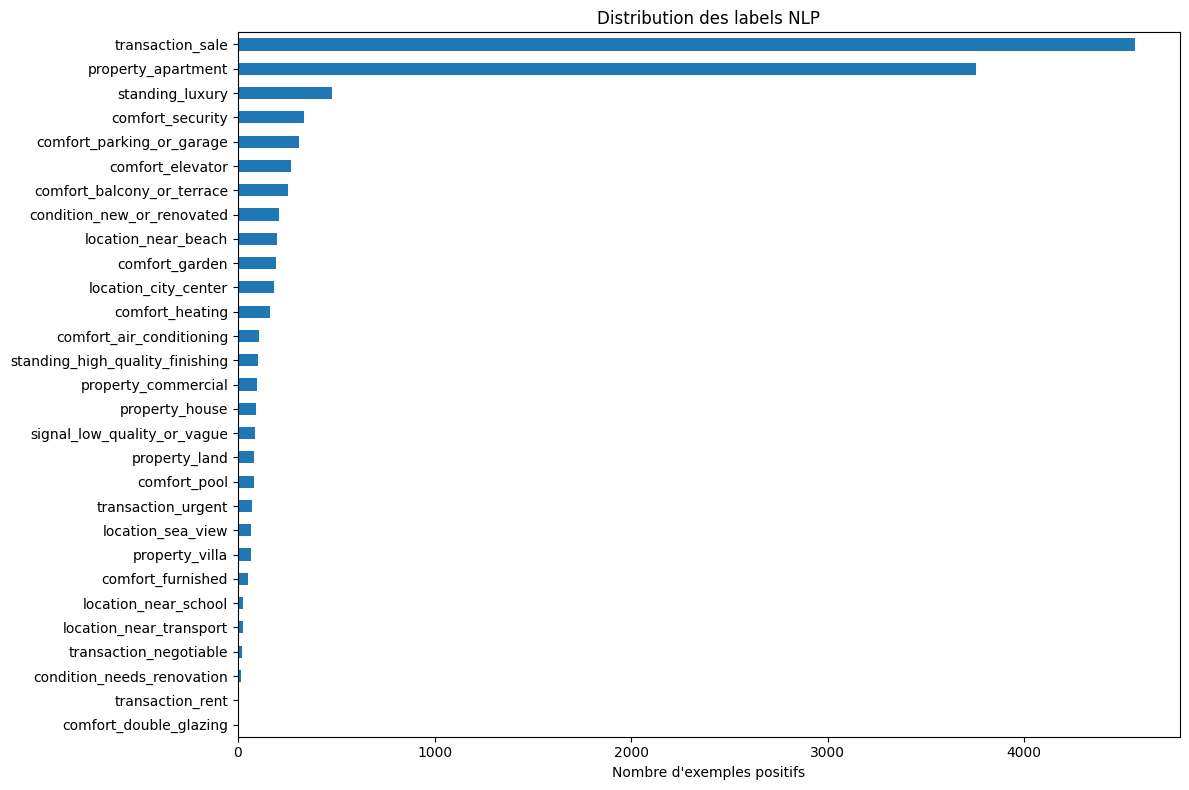

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
label_distribution.sort_values("positive_count")["positive_count"].plot(kind="barh")
plt.title("Distribution des labels NLP")
plt.xlabel("Nombre d'exemples positifs")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "label_distribution.png", dpi=200)
plt.show()

## 8. Labels entraînables

In [9]:
MIN_POSITIVES = 10
MIN_NEGATIVES = 10
trainable_labels, skipped_labels = [], []

for label in LABELS:
    positives = int(y_all[label].sum())
    negatives = int(len(y_all) - positives)
    if positives >= MIN_POSITIVES and negatives >= MIN_NEGATIVES:
        trainable_labels.append(label)
    else:
        skipped_labels.append({"label": label, "positives": positives, "negatives": negatives})

print("✅ Labels totaux:", len(LABELS))
print("✅ Labels entraînables:", len(trainable_labels))
print("⚠️ Labels skippés:", len(skipped_labels))
if skipped_labels:
    display(pd.DataFrame(skipped_labels))

y = y_all[trainable_labels].astype(int).values
texts = df["nlp_text"].astype(str).values
print("Shape y:", y.shape)
if len(trainable_labels) == 0:
    raise ValueError("Aucun label entraînable")

✅ Labels totaux: 29
✅ Labels entraînables: 27
⚠️ Labels skippés: 2


,label,positives,negatives
0,transaction_rent,2,9926
1,comfort_double_glazing,0,9928


Shape y: (9928, 27)


## 9. Split Train / Validation / Test

In [10]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(df))
idx_train_val, idx_test = train_test_split(indices, test_size=TEST_SIZE, random_state=SEED)
idx_train, idx_val = train_test_split(idx_train_val, test_size=VAL_SIZE, random_state=SEED)

X_train_text, X_val_text, X_test_text = texts[idx_train], texts[idx_val], texts[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
df_train, df_val, df_test = df.iloc[idx_train].reset_index(drop=True), df.iloc[idx_val].reset_index(drop=True), df.iloc[idx_test].reset_index(drop=True)

print("Train:", len(X_train_text), y_train.shape)
print("Val:", len(X_val_text), y_val.shape)
print("Test:", len(X_test_text), y_test.shape)

Train: 7147 (7147, 27)
Val: 795 (795, 27)
Test: 1986 (1986, 27)


## 10. Métriques et optimisation des seuils

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, accuracy_score, jaccard_score, classification_report

results = []
prediction_store = {}
threshold_store = {}


def optimize_thresholds(y_true, y_scores):
    thresholds = []
    grid = np.arange(0.10, 0.91, 0.05)
    for j in range(y_true.shape[1]):
        best_t, best_f1 = 0.5, -1
        for t in grid:
            pred = (y_scores[:, j] >= t).astype(int)
            f1 = f1_score(y_true[:, j], pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds.append(best_t)
    return np.array(thresholds)


def apply_thresholds(scores, thresholds):
    return (scores >= thresholds.reshape(1, -1)).astype(int)


def evaluate_model(model_name, y_true, y_scores=None, y_pred=None, thresholds=None, note=""):
    if y_pred is None:
        if thresholds is None:
            thresholds = np.full(y_true.shape[1], 0.5)
        y_pred = apply_thresholds(y_scores, thresholds)

    metrics = {
        "model": model_name,
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "subset_accuracy": accuracy_score(y_true, y_pred),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
        "note": note,
    }
    results.append(metrics)
    prediction_store[model_name] = {"scores": y_scores, "pred": y_pred}
    if thresholds is not None:
        threshold_store[model_name] = thresholds
    print("✅", model_name)
    print(json.dumps(metrics, indent=2, ensure_ascii=False))
    return metrics

## 11. Architecture globale

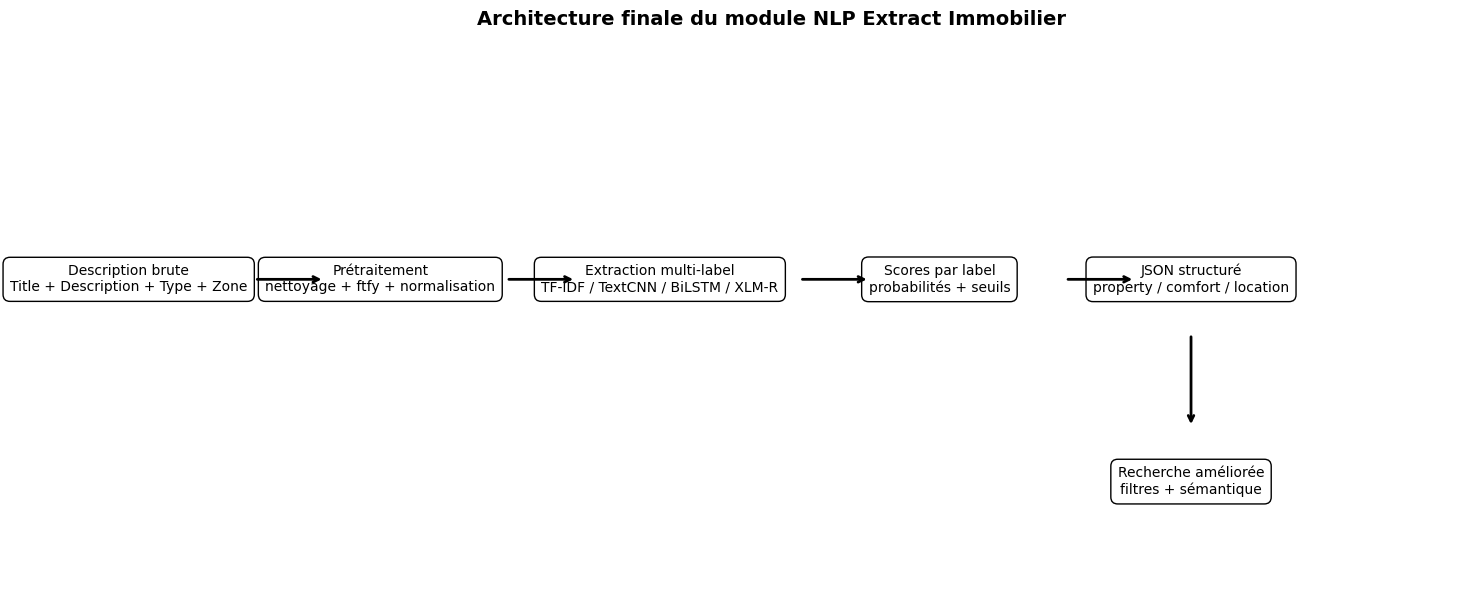

In [12]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.axis("off")
boxes = [
    ("Description brute\nTitle + Description + Type + Zone", 0.04, 0.55),
    ("Prétraitement\nnettoyage + ftfy + normalisation", 0.22, 0.55),
    ("Extraction multi-label\nTF-IDF / TextCNN / BiLSTM / XLM-R", 0.42, 0.55),
    ("Scores par label\nprobabilités + seuils", 0.62, 0.55),
    ("JSON structuré\nproperty / comfort / location", 0.80, 0.55),
    ("Recherche améliorée\nfiltres + sémantique", 0.80, 0.18),
]
for text, x, yb in boxes:
    ax.text(x, yb, text, ha="center", va="center", fontsize=10, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black"))
for x1,y1,x2,y2 in [(0.13,0.55,0.18,0.55),(0.31,0.55,0.36,0.55),(0.52,0.55,0.57,0.55),(0.71,0.55,0.76,0.55),(0.80,0.45,0.80,0.28)]:
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1), arrowprops=dict(arrowstyle="->", lw=2))
ax.set_title("Architecture finale du module NLP Extract Immobilier", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "architecture_nlp_extract.png", dpi=200)
plt.show()

## 12. Modèle 1 — Rule-based Lexicon

Baseline explicable. Si labels = silver labels, son score peut être artificiel.

In [13]:
if RUN_RULE_BASED:
    y_rule_all = silver[trainable_labels].astype(int).values
    y_rule_test = y_rule_all[idx_test]
    evaluate_model("Rule-based Lexicon", y_test, y_pred=y_rule_test, note="Baseline explicable; score artificiel si labels=silver_labels")

✅ Rule-based Lexicon
{
  "model": "Rule-based Lexicon",
  "precision_micro": 1.0,
  "recall_micro": 1.0,
  "f1_micro": 1.0,
  "precision_macro": 1.0,
  "recall_macro": 1.0,
  "f1_macro": 1.0,
  "hamming_loss": 0.0,
  "subset_accuracy": 1.0,
  "jaccard_samples": 0.5568982880161127,
  "note": "Baseline explicable; score artificiel si labels=silver_labels"
}


## 13. Modèle 2 — TF-IDF + Logistic Regression

Architecture classique : texte → TF-IDF → Logistic Regression One-vs-Rest.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

if RUN_TFIDF:
    tfidf_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=80000, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ("clf", OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)))
    ])
    print("🔄 Entraînement TF-IDF...")
    tfidf_model.fit(X_train_text, y_train)
    val_scores = tfidf_model.predict_proba(X_val_text)
    test_scores = tfidf_model.predict_proba(X_test_text)
    thresholds = optimize_thresholds(y_val, val_scores)
    evaluate_model("TF-IDF + LogisticRegression", y_test, y_scores=test_scores, thresholds=thresholds)

🔄 Entraînement TF-IDF...
✅ TF-IDF + LogisticRegression
{
  "model": "TF-IDF + LogisticRegression",
  "precision_micro": 0.926790660862683,
  "recall_micro": 0.9657731958762886,
  "f1_micro": 0.9458804523424879,
  "precision_macro": 0.8338204968307641,
  "recall_macro": 0.89152225542422,
  "f1_macro": 0.8374775763723842,
  "hamming_loss": 0.00499794860318526,
  "subset_accuracy": 0.8902316213494461,
  "jaccard_samples": 0.5162732380632682,
  "note": ""
}


## 14. Tokenization Deep Learning

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

# Très important : empêcher TensorFlow de réserver toute la mémoire GPU.
try:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ TensorFlow GPU memory growth activé")
except Exception as e:
    print("ℹ️ Memory growth non appliqué :", e)

tf.random.set_seed(SEED)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_text), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
n_labels = len(trainable_labels)
print("Vocab size:", vocab_size, "| Labels:", n_labels)


✅ TensorFlow GPU memory growth activé
Vocab size: 6279 | Labels: 27


## 15. Modèle 3 — TextCNN

Architecture : Embedding → Conv1D → GlobalMaxPooling → Dense sigmoid.

In [16]:
if RUN_TEXTCNN:
    def build_textcnn():
        inp = layers.Input(shape=(MAX_LEN,))
        x = layers.Embedding(vocab_size, 128)(inp)
        convs = []
        for k in [3, 4, 5]:
            c = layers.Conv1D(128, k, activation="relu", padding="same")(x)
            c = layers.GlobalMaxPooling1D()(c)
            convs.append(c)
        x = layers.Concatenate()(convs)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(128, activation="relu")(x)
        x = layers.Dropout(0.3)(x)
        out = layers.Dense(n_labels, activation="sigmoid")(x)
        model = models.Model(inp, out)
        model.compile(optimizer="adam", loss="binary_crossentropy")
        return model

    textcnn = build_textcnn()
    textcnn.summary()
    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
    textcnn.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=EPOCHS_DEEP, batch_size=BATCH_SIZE_DEEP, callbacks=cb, verbose=1)
    val_scores = textcnn.predict(X_val_seq, batch_size=256)
    test_scores = textcnn.predict(X_test_seq, batch_size=256)
    thresholds = optimize_thresholds(y_val, val_scores)
    evaluate_model("TextCNN", y_test, y_scores=test_scores, thresholds=thresholds)
    TEXTCNN_PATH = ARTIFACT_DIR / "textcnn_model.keras"
    textcnn.save(TEXTCNN_PATH)
    print("✅ TextCNN sauvegardé :", TEXTCNN_PATH)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 180, 128)  │    803,712 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 180, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 180, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 180, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 27)        │      3,483 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,053,467 (4.02 MB)

 Trainable params: 1,053,467 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - loss: 0.1502 - val_loss: 0.0653
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0614 - val_loss: 0.0499
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0463 - val_loss: 0.0407
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
✅ TextCNN
{
  "model": "TextCNN",
  "precision_micro": 0.8594798657718121,
  "recall_micro": 0.8449484536082474,
  "f1_micro": 0.8521522145976295,
  "precision_macro": 0.43163874169328087,
  "recall_macro": 0.37696242387302226,
  "f1_macro": 0.3714664220148101,
  "hamming_loss": 0.013259483048002686,
  "subset_accuracy": 0.8121852970795569,
  "jaccard_samples": 0.46859026847475393,
  "note": ""
}
✅ TextCNN sauvegardé : /content/nlp_extract_artifacts/textcnn_model.keras


## 16. Modèle 4 — BiLSTM + Attention

Architecture : Embedding → BiLSTM bidirectionnel → Attention → Dense sigmoid.

In [17]:
class SimpleAttention(layers.Layer):
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super().build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        return tf.keras.backend.sum(x * a, axis=1)

if RUN_BILSTM_ATTENTION:
    def build_bilstm_attention():
        inp = layers.Input(shape=(MAX_LEN,))
        x = layers.Embedding(vocab_size, 128)(inp)
        x = layers.Bidirectional(layers.LSTM(96, return_sequences=True, dropout=0.2))(x)
        x = SimpleAttention()(x)
        x = layers.Dense(128, activation="relu")(x)
        x = layers.Dropout(0.4)(x)
        out = layers.Dense(n_labels, activation="sigmoid")(x)
        model = models.Model(inp, out)
        model.compile(optimizer="adam", loss="binary_crossentropy")
        return model

    bilstm = build_bilstm_attention()
    bilstm.summary()
    cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
    bilstm.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=EPOCHS_DEEP, batch_size=BATCH_SIZE_DEEP, callbacks=cb, verbose=1)
    val_scores = bilstm.predict(X_val_seq, batch_size=256)
    test_scores = bilstm.predict(X_test_seq, batch_size=256)
    thresholds = optimize_thresholds(y_val, val_scores)
    evaluate_model("BiLSTM + Attention", y_test, y_scores=test_scores, thresholds=thresholds)
    BILSTM_PATH = ARTIFACT_DIR / "bilstm_attention_model.keras"
    bilstm.save(BILSTM_PATH)
    print("✅ BiLSTM sauvegardé :", BILSTM_PATH)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 180, 128)       │       803,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 180, 192)       │       172,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_attention                │ (None, 192)            │           372 │
│ (SimpleAttention)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,005,071 (3.83 MB)

 Trainable params: 1,005,071 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.1577 - val_loss: 0.0832
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0831 - val_loss: 0.0717
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0703 - val_loss: 0.0649
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
✅ BiLSTM + Attention
{
  "model": "BiLSTM + Attention",
  "precision_micro": 0.6931818181818182,
  "recall_micro": 0.7294845360824742,
  "f1_micro": 0.7108700020092426,
  "precision_macro": 0.2829846822277725,
  "recall_macro": 0.26898362477300025,
  "f1_macro": 0.2428723071406642,
  "hamming_loss": 0.026836000149192494,
  "subset_accuracy": 0.6722054380664653,
  "jaccard_samples": 0.34229782782297435,
  "note": ""
}
✅ BiLSTM sauvegardé : /content/nlp_extract_artifacts/bilstm_attention_model.keras


## 17. Modèle 5 — Transformer Encoder multilingual

Architecture Transformer Encoder-only. Version GPU-safe : libération de la mémoire TensorFlow, batch réduit, gradient accumulation, fallback CPU si CUDA OOM.

In [19]:
if RUN_TRANSFORMER:
    import gc
    import torch
    from torch.utils.data import Dataset
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

    # ============================================================
    # Libération mémoire avant PyTorch / HuggingFace
    # Cause du bug précédent : TensorFlow gardait presque toute la VRAM.
    # ============================================================
    if RELEASE_TF_GPU_BEFORE_TRANSFORMER:
        print("🧹 Libération mémoire GPU avant Transformer...")
        try:
            if "textcnn" in globals():
                del textcnn
            if "bilstm" in globals():
                del bilstm
            tf.keras.backend.clear_session()
        except Exception as e:
            print("ℹ️ Nettoyage TensorFlow partiel :", e)
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
            print("Mémoire GPU libre après nettoyage:", round(torch.cuda.mem_get_info()[0] / 1024**3, 2), "GB")

    class MultiLabelTextDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_length=128):
            self.texts = list(texts)
            self.labels = labels.astype(np.float32)
            self.tokenizer = tokenizer
            self.max_length = max_length
        def __len__(self):
            return len(self.texts)
        def __getitem__(self, idx):
            enc = self.tokenizer(
                self.texts[idx],
                truncation=True,
                padding="max_length",
                max_length=self.max_length,
                return_tensors="pt"
            )
            item = {k: v.squeeze(0) for k, v in enc.items()}
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
            return item

    def make_training_args(output_dir, use_cpu=False, epochs=None, batch_size=None):
        epochs = EPOCHS_TRANSFORMER if epochs is None else epochs
        batch_size = BATCH_SIZE_TRANSFORMER if batch_size is None else batch_size
        args_kwargs = dict(
            output_dir=str(output_dir),
            learning_rate=2e-5,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            gradient_accumulation_steps=TRANSFORMER_GRADIENT_ACCUMULATION,
            num_train_epochs=epochs,
            weight_decay=0.01,
            logging_steps=100,
            save_strategy="no",
            report_to="none",
            fp16=(torch.cuda.is_available() and not use_cpu),
            seed=SEED,
            dataloader_num_workers=0,
        )
        # Compatibilité entre versions transformers
        if use_cpu:
            args_kwargs["no_cuda"] = True
        try:
            return TrainingArguments(eval_strategy="epoch", **args_kwargs)
        except TypeError:
            try:
                return TrainingArguments(evaluation_strategy="epoch", **args_kwargs)
            except TypeError:
                args_kwargs.pop("no_cuda", None)
                if use_cpu:
                    args_kwargs["use_cpu"] = True
                try:
                    return TrainingArguments(eval_strategy="epoch", **args_kwargs)
                except TypeError:
                    return TrainingArguments(evaluation_strategy="epoch", **args_kwargs)

    def run_transformer_once(train_rows, max_length, use_cpu=False, epochs=None, batch_size=None, run_name="transformer_run"):
        train_limit = len(X_train_text) if train_rows is None else min(len(X_train_text), train_rows)
        val_limit = min(len(X_val_text), max(200, int(train_limit * 0.15)))
        test_limit = min(len(X_test_text), max(300, int(train_limit * 0.20)))

        Xtr_t, ytr_t = X_train_text[:train_limit], y_train[:train_limit]
        Xva_t, yva_t = X_val_text[:val_limit], y_val[:val_limit]
        Xte_t, yte_t = X_test_text[:test_limit], y_test[:test_limit]

        print(f"Transformer train/val/test: {len(Xtr_t)} / {len(Xva_t)} / {len(Xte_t)}")
        print("Model:", TRANSFORMER_MODEL_NAME, "| max_length:", max_length, "| batch:", batch_size or BATCH_SIZE_TRANSFORMER, "| CPU:", use_cpu)

        hf_tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)
        train_ds = MultiLabelTextDataset(Xtr_t, ytr_t, hf_tokenizer, max_length=max_length)
        val_ds = MultiLabelTextDataset(Xva_t, yva_t, hf_tokenizer, max_length=max_length)
        test_ds = MultiLabelTextDataset(Xte_t, yte_t, hf_tokenizer, max_length=max_length)

        hf_model = AutoModelForSequenceClassification.from_pretrained(
            TRANSFORMER_MODEL_NAME,
            num_labels=n_labels,
            problem_type="multi_label_classification",
            ignore_mismatched_sizes=True
        )

        training_args = make_training_args(ARTIFACT_DIR / run_name, use_cpu=use_cpu, epochs=epochs, batch_size=batch_size)
        trainer = Trainer(model=hf_model, args=training_args, train_dataset=train_ds, eval_dataset=val_ds)


        print("🔄 Entraînement Transformer Encoder...")
        trainer.train()

        val_logits = trainer.predict(val_ds).predictions
        test_logits = trainer.predict(test_ds).predictions
        val_scores = 1 / (1 + np.exp(-val_logits))
        test_scores = 1 / (1 + np.exp(-test_logits))
        thresholds = optimize_thresholds(yva_t, val_scores)
        evaluate_model(f"Transformer Encoder ({TRANSFORMER_MODEL_NAME})", yte_t, y_scores=test_scores, thresholds=thresholds)

        # Nettoyage pour laisser la suite du notebook respirer
        del trainer, hf_model, train_ds, val_ds, test_ds
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return True

    transformer_ok = False
    try:
        transformer_ok = run_transformer_once(
            train_rows=MAX_TRANSFORMER_ROWS,
            max_length=TRANSFORMER_MAX_LENGTH,
            use_cpu=False,
            epochs=EPOCHS_TRANSFORMER,
            batch_size=BATCH_SIZE_TRANSFORMER,
            run_name="transformer_gpu_run"
        )
    except torch.cuda.OutOfMemoryError as e:
        print("⚠️ CUDA OOM pendant Transformer :", str(e)[:300])
        print("➡️ Retry automatique avec échantillon plus petit et CPU fallback.")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if TRANSFORMER_CPU_FALLBACK:
            transformer_ok = run_transformer_once(
                train_rows=min(600, len(X_train_text)),
                max_length=96,
                use_cpu=True,
                epochs=1,
                batch_size=2,
                run_name="transformer_cpu_fallback"
            )
        else:
            print("❌ CPU fallback désactivé. Transformer non évalué.")
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("⚠️ Runtime OOM pendant Transformer :", str(e)[:300])
            print("➡️ Retry automatique CPU avec petit échantillon.")
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            if TRANSFORMER_CPU_FALLBACK:
                transformer_ok = run_transformer_once(
                    train_rows=min(600, len(X_train_text)),
                    max_length=96,
                    use_cpu=True,
                    epochs=1,
                    batch_size=2,
                    run_name="transformer_cpu_fallback"
                )
        else:
            raise e


🧹 Libération mémoire GPU avant Transformer...
Mémoire GPU libre après nettoyage: 1.0 GB
Transformer train/val/test: 2000 / 300 / 400
Model: distilbert-base-multilingual-cased | max_length: 128 | batch: 2 | CPU: False


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔄 Entraînement Transformer Encoder...
⚠️ CUDA OOM pendant Transformer : CUDA out of memory. Tried to allocate 352.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 263.81 MiB is free. Including non-PyTorch memory, this process has 14.30 GiB memory in use. Of the allocated memory 700.39 MiB is allocated by PyTorch, and 29.61 MiB is reserved by PyTorch but unalloca
➡️ Retry automatique avec échantillon plus petit et CPU fallback.
Transformer train/val/test: 600 / 200 / 300
Model: distilbert-base-multilingual-cased | max_length: 96 | batch: 2 | CPU: True


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔄 Entraînement Transformer Encoder...


Epoch,Training Loss,Validation Loss
1,No log,0.354574


✅ Transformer Encoder (distilbert-base-multilingual-cased)
{
  "model": "Transformer Encoder (distilbert-base-multilingual-cased)",
  "precision_micro": 0.051414581066376495,
  "recall_micro": 0.949748743718593,
  "f1_micro": 0.0975483870967742,
  "precision_macro": 0.06402314476971459,
  "recall_macro": 0.8484370895718414,
  "f1_macro": 0.08779669333417431,
  "hamming_loss": 0.8634567901234568,
  "subset_accuracy": 0.0,
  "jaccard_samples": 0.049756362773029444,
  "note": ""
}


## 18. Comparaison finale

,model,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,hamming_loss,subset_accuracy,jaccard_samples,note
0,Rule-based Lexicon,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.556898,Baseline explicable; score artificiel si label...
1,TF-IDF + LogisticRegression,0.926791,0.965773,0.945880,0.833820,0.891522,0.837478,0.004998,0.890232,0.516273,
2,TextCNN,0.859480,0.844948,0.852152,0.431639,0.376962,0.371466,0.013259,0.812185,0.468590,
3,BiLSTM + Attention,0.693182,0.729485,0.710870,0.282985,0.268984,0.242872,0.026836,0.672205,0.342298,
4,Transformer Encoder (distilbert-base-multiling...,0.051415,0.949749,0.097548,0.064023,0.848437,0.087797,0.863457,0.000000,0.049756,


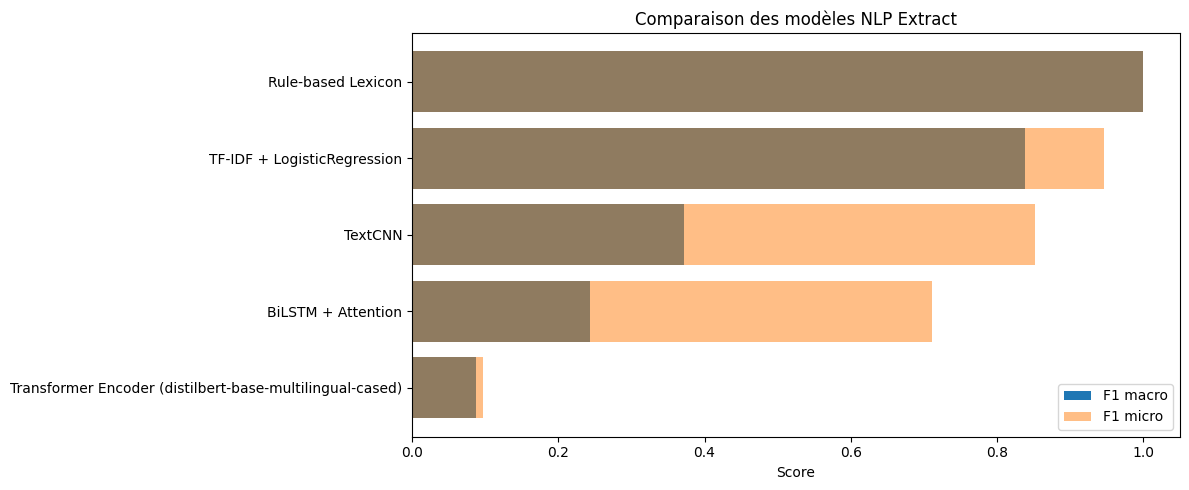

In [20]:
results_df = pd.DataFrame(results).sort_values(["f1_macro", "f1_micro"], ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(ARTIFACT_DIR / "model_comparison_results.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(12, 5))
plot_df = results_df.sort_values("f1_macro")
plt.barh(plot_df["model"], plot_df["f1_macro"], label="F1 macro")
plt.barh(plot_df["model"], plot_df["f1_micro"], alpha=0.5, label="F1 micro")
plt.xlabel("Score")
plt.title("Comparaison des modèles NLP Extract")
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "model_comparison_f1.png", dpi=200)
plt.show()

## 19. Choix du meilleur modèle

In [21]:
eligible_results = results_df.copy()
if not using_manual_gold:
    eligible_results = eligible_results[~eligible_results["model"].str.contains("Rule-based", case=False, na=False)].copy()
if len(eligible_results) == 0:
    eligible_results = results_df.copy()

best_row = eligible_results.sort_values(["f1_macro", "f1_micro"], ascending=False).iloc[0]
BEST_MODEL_NAME = best_row["model"]
print("🏆 Meilleur modèle pratique:", BEST_MODEL_NAME)
print("F1 macro:", best_row["f1_macro"])
print("F1 micro:", best_row["f1_micro"])
if not using_manual_gold:
    print("ℹ️ Rule-based exclu du choix final car labels=silver_labels")

deep_models = results_df[results_df["model"].str.contains("TextCNN|BiLSTM|Transformer", case=False, na=False)].copy()
if len(deep_models) > 0:
    best_deep = deep_models.sort_values(["f1_macro", "f1_micro"], ascending=False).iloc[0]
    BEST_DEEP_MODEL_NAME = best_deep["model"]
    print("🧠 Meilleur modèle deep learning:", BEST_DEEP_MODEL_NAME)
    print("F1 macro DL:", best_deep["f1_macro"])
    print("F1 micro DL:", best_deep["f1_micro"])
else:
    BEST_DEEP_MODEL_NAME = None

🏆 Meilleur modèle pratique: TF-IDF + LogisticRegression
F1 macro: 0.8374775763723842
F1 micro: 0.9458804523424879
ℹ️ Rule-based exclu du choix final car labels=silver_labels
🧠 Meilleur modèle deep learning: TextCNN
F1 macro DL: 0.3714664220148101
F1 micro DL: 0.8521522145976295


## 20. Rapport par label

,precision,recall,f1-score,support
standing_high_quality_finishing,1.000000,1.000000,1.000000,17.0
location_near_beach,0.976190,1.000000,0.987952,41.0
transaction_sale,0.982590,0.992308,0.987425,910.0
standing_luxury,0.954128,1.000000,0.976526,104.0
property_house,0.944444,1.000000,0.971429,17.0
comfort_elevator,0.960526,0.960526,0.960526,76.0
signal_low_quality_or_vague,1.000000,0.904762,0.950000,21.0
property_apartment,0.933333,0.959897,0.946429,773.0
comfort_parking_or_garage,0.903226,0.982456,0.941176,57.0
property_commercial,0.952381,0.869565,0.909091,23.0


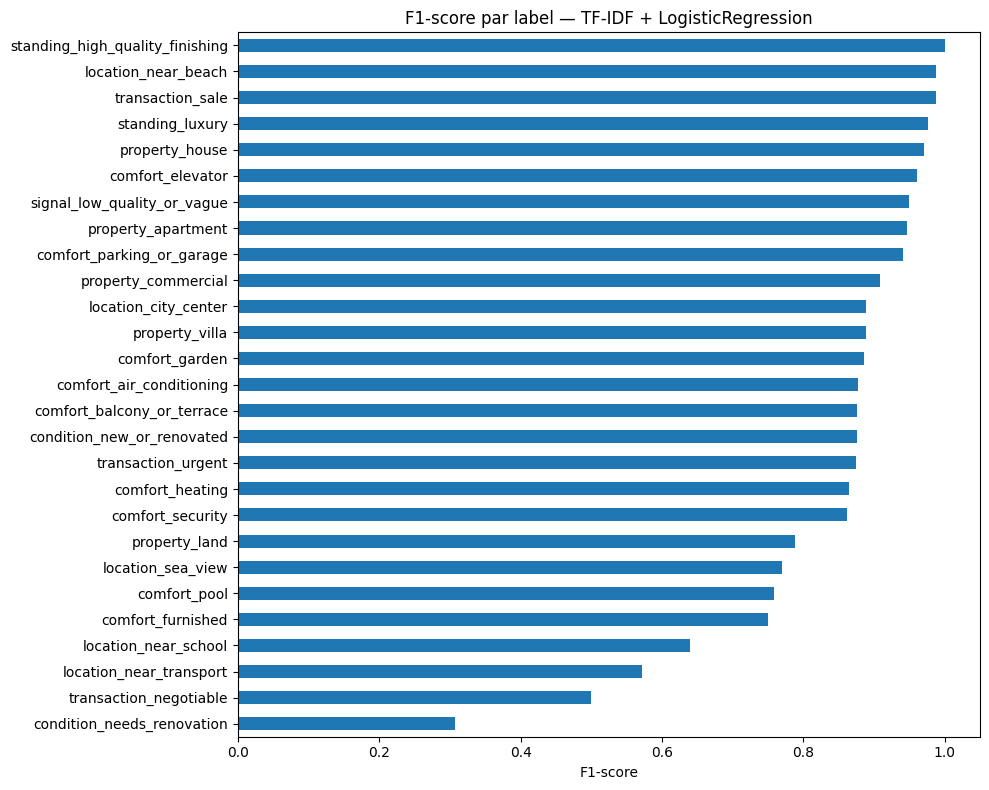

In [22]:
best_pred = prediction_store[BEST_MODEL_NAME]["pred"]
y_ref = y_test if best_pred.shape[0] == y_test.shape[0] else y_test[:best_pred.shape[0]]
report = classification_report(y_ref, best_pred, target_names=trainable_labels, output_dict=True, zero_division=0)
per_label_df = pd.DataFrame(report).T
per_label_labels = per_label_df.loc[trainable_labels].copy()
per_label_labels.to_csv(ARTIFACT_DIR / "per_label_reports.csv", encoding="utf-8-sig")
display(per_label_labels.sort_values("f1-score", ascending=False))

plt.figure(figsize=(10, 8))
per_label_labels["f1-score"].sort_values().plot(kind="barh")
plt.title(f"F1-score par label — {BEST_MODEL_NAME}")
plt.xlabel("F1-score")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "best_model_per_label_f1.png", dpi=200)
plt.show()

## 21. Génération JSON structuré

In [23]:
def labels_to_structured_json(label_values, confidence=None):
    d = {l: int(label_values.get(l, 0)) for l in LABELS}
    return {
        "property": {"apartment": bool(d["property_apartment"]), "house": bool(d["property_house"]), "villa": bool(d["property_villa"]), "land": bool(d["property_land"]), "commercial": bool(d["property_commercial"])},
        "transaction": {"sale": bool(d["transaction_sale"]), "rent": bool(d["transaction_rent"]), "negotiable": bool(d["transaction_negotiable"]), "urgent": bool(d["transaction_urgent"])},
        "condition": {"new_or_renovated": bool(d["condition_new_or_renovated"]), "needs_renovation": bool(d["condition_needs_renovation"])},
        "comfort": {"furnished": bool(d["comfort_furnished"]), "air_conditioning": bool(d["comfort_air_conditioning"]), "heating": bool(d["comfort_heating"]), "parking_or_garage": bool(d["comfort_parking_or_garage"]), "elevator": bool(d["comfort_elevator"]), "balcony_or_terrace": bool(d["comfort_balcony_or_terrace"]), "garden": bool(d["comfort_garden"]), "pool": bool(d["comfort_pool"]), "security": bool(d["comfort_security"]), "double_glazing": bool(d["comfort_double_glazing"])},
        "location": {"sea_view": bool(d["location_sea_view"]), "near_beach": bool(d["location_near_beach"]), "near_school": bool(d["location_near_school"]), "near_transport": bool(d["location_near_transport"]), "city_center": bool(d["location_city_center"])},
        "standing": {"luxury": bool(d["standing_luxury"]), "high_quality_finishing": bool(d["standing_high_quality_finishing"])},
        "signals": {"low_quality_or_vague": bool(d["signal_low_quality_or_vague"]), "extraction_confidence": None if confidence is None else float(confidence)}
    }

print("Modèle utilisé pour générer le dataset structuré :", BEST_MODEL_NAME)

if BEST_MODEL_NAME == "TF-IDF + LogisticRegression":
    all_scores_trainable = tfidf_model.predict_proba(df["nlp_text"].astype(str).values)
    all_pred_trainable = apply_thresholds(all_scores_trainable, threshold_store[BEST_MODEL_NAME])
elif BEST_MODEL_NAME == "TextCNN":
    all_seq = pad_sequences(tokenizer.texts_to_sequences(df["nlp_text"].astype(str).values), maxlen=MAX_LEN, padding="post", truncating="post")
    if "textcnn" not in globals() and "TEXTCNN_PATH" in globals() and TEXTCNN_PATH.exists():
        print("🔄 Rechargement TextCNN depuis disque...")
        textcnn = tf.keras.models.load_model(TEXTCNN_PATH)
    all_scores_trainable = textcnn.predict(all_seq, batch_size=256)
    all_pred_trainable = apply_thresholds(all_scores_trainable, threshold_store[BEST_MODEL_NAME])
elif BEST_MODEL_NAME == "BiLSTM + Attention":
    all_seq = pad_sequences(tokenizer.texts_to_sequences(df["nlp_text"].astype(str).values), maxlen=MAX_LEN, padding="post", truncating="post")
    if "bilstm" not in globals() and "BILSTM_PATH" in globals() and BILSTM_PATH.exists():
        print("🔄 Rechargement BiLSTM depuis disque...")
        bilstm = tf.keras.models.load_model(BILSTM_PATH, custom_objects={"SimpleAttention": SimpleAttention})
    all_scores_trainable = bilstm.predict(all_seq, batch_size=256)
    all_pred_trainable = apply_thresholds(all_scores_trainable, threshold_store[BEST_MODEL_NAME])
else:
    print("Fallback vers silver labels pour extraction globale complète")
    all_pred_trainable = silver[trainable_labels].astype(int).values

full_pred = pd.DataFrame(0, index=np.arange(len(df)), columns=LABELS)
for j, label in enumerate(trainable_labels):
    full_pred[label] = all_pred_trainable[:, j]
for label in LABELS:
    if label not in trainable_labels:
        full_pred[label] = silver[label].values

enriched = df.copy()
for label in LABELS:
    enriched[f"nlp_{label}"] = full_pred[label].astype(int)

# Choisir des exemples riches, pas des lignes vides.
example_candidates = enriched[enriched["nlp_text"].astype(str).str.len() > 80].head(10)
if len(example_candidates) == 0:
    example_candidates = enriched.head(10)

samples = []
for idx in example_candidates.index[:10]:
    label_dict = full_pred.loc[idx].to_dict()
    samples.append({"nlp_text": enriched.loc[idx, "nlp_text"], "structured_json": labels_to_structured_json(label_dict)})

json_path = ARTIFACT_DIR / "structured_json_samples.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(samples, f, ensure_ascii=False, indent=2)

csv_path = ARTIFACT_DIR / "nlp_extracted_structured.csv"
enriched.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("✅ Dataset enrichi exporté:", csv_path)
print("✅ JSON samples:", json_path)
print(json.dumps(samples[0], indent=2, ensure_ascii=False) if samples else "Aucun sample")


Modèle utilisé pour générer le dataset structuré : TF-IDF + LogisticRegression
✅ Dataset enrichi exporté: /content/nlp_extract_artifacts/nlp_extracted_structured.csv
✅ JSON samples: /content/nlp_extract_artifacts/structured_json_samples.json
{
  "nlp_text": "Description: \"Réf: AH079 Nabeul / Hammamet centre Appartement / à vendre il y a 3 jours 🏢#MS_IMMOBILIER🏢met en #vente🎉un #appartement richement #meublé de type🔑S+1 avec une grande #terrasse aménagée🚶🚶 ayant une #vue_sublime sur la #mer🏝🏖 mis au 2ème étage d'une petite #résidence #conviviale à #Hammamet_centre-ville ⛱️🌊 🎉Une terrasse #vue de #mer est disponible🏡 🌊🔌 Chauffage central préinstallé 📜 Documents: Titre foncier individuel encours 📐Superficie: 76 m² 💰 Prix: 320 MD 👋 Réf : AH079 👉Pour plus d'informations contactez-nous sur ☎51355351 | Transaction type: vente",
  "structured_json": {
    "property": {
      "apartment": true,
      "house": false,
      "villa": false,
      "land": false,
      "commercial": false
    },
  

## 22. Recherche structurée améliorée

In [24]:
query_filters = {"nlp_comfort_parking_or_garage": 1, "nlp_standing_luxury": 1}
filtered = enriched.copy()
for col, val in query_filters.items():
    if col in filtered.columns:
        filtered = filtered[filtered[col] == val]

print("Résultats recherche structurée:", filtered.shape)
cols_to_show = [c for c in ["nlp_text", COL_PRICE, COL_SURFACE, COL_LOCATION, COL_PROPERTY_TYPE] if c is not None and c in filtered.columns]
display(filtered[cols_to_show].head(10))

Résultats recherche structurée: (21, 79)


,nlp_text,prix,surface,ville,type
11,"Description: ""Réf: AV1962 Nabeul / Hammamet no...",None,None,,
135,"Description: ""Réf: AV1874 Nabeul / Hammamet Vi...",None,None,,
147,"Description: ""Réf: AV1884 Nabeul / Hammamet Ap...",None,None,,
186,"Description: ""Réf: AV1815 Nabeul / Nabeul Appa...",None,None,,
349,"Description: ""Réf: OF90418 Ariana / Ariana ess...",None,None,,
354,"Description: ""Réf: OF90439 Ben arous / El mour...",None,None,,
386,"Description: ""Ariana / Borj louzir Appartement...",None,None,,
388,"Description: ""Ariana / Mnihla Appartement / à ...",None,None,,
707,Title: [Réf:3220981] Etage de villa pour famil...,420000.0,200.0,Akouda,Appartement
901,Title: [Réf:3126942] Appartement haut standing...,325000.0,100.0,Sousse Jaouhara,Appartement


## 23. Recherche sémantique avec Sentence-BERT

In [26]:
# =========================
# SEMANTIC SEARCH GPU-SAFE
# Sentence-BERT chargé sur CPU pour éviter CUDA OutOfMemory
# =========================

if RUN_SEMANTIC_SEARCH:
    import gc
    import torch
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity

    # Libérer un peu de mémoire GPU avant Sentence-BERT
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Échantillon réduit pour éviter RAM/GPU overload
    semantic_sample_size = min(2000, len(enriched))
    semantic_df = enriched.sample(
        semantic_sample_size,
        random_state=SEED
    ).reset_index(drop=True)

    print("🔄 Chargement Sentence-BERT sur CPU pour éviter CUDA OOM...")

    # Très important : device="cpu"
    sbert = SentenceTransformer(
        SENTENCE_BERT_MODEL,
        device="cpu"
    )

    print("🔄 Encodage embeddings sur CPU...")
    embeddings = sbert.encode(
        semantic_df["nlp_text"].astype(str).tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    def semantic_search(query, top_k=5):
        q_emb = sbert.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        sims = cosine_similarity(q_emb, embeddings)[0]
        top_idx = np.argsort(-sims)[:top_k]

        res = semantic_df.iloc[top_idx].copy()
        res["semantic_score"] = sims[top_idx]

        return res

    demo_query = "appartement haut standing proche plage avec parking et climatisation"

    sem_results = semantic_search(demo_query, top_k=5)

    print("✅ Recherche sémantique terminée")
    print("Query:", demo_query)

    display(sem_results[["semantic_score", "nlp_text"]].head())

🔄 Chargement Sentence-BERT sur CPU pour éviter CUDA OOM...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔄 Encodage embeddings sur CPU...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

✅ Recherche sémantique terminée
Query: appartement haut standing proche plage avec parking et climatisation


,semantic_score,nlp_text
804,0.760966,"Title: ""appartement à 200 mètres de la plage"
1793,0.661794,"Zone: ""𝔸 𝕍𝔼ℕ𝔻ℝ𝔼 un appartement S+3 de très ha..."
1080,0.651751,Title: Des appartements à vendre à proximité d...
1196,0.648187,"Title: ""appartements s+2 à 100 m de la plage d..."
293,0.641535,"Description: ""A vendre appartement haut standi..."


## 24. FLAN-T5 vers JSON — démonstration Encoder-Decoder

Cette partie est innovante mais pas choisie comme modèle final sans fine-tuning spécifique.

In [27]:
if RUN_T5_JSON_GENERATION:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    import torch

    t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
    t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_NAME)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    t5_model.to(device)

    def generate_json_with_t5(text):
        prompt = f"""Extract real estate information as JSON with keys property, transaction, comfort, location, standing.
Text: {text}
JSON:"""
        inputs = t5_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
        outputs = t5_model.generate(**inputs, max_new_tokens=160, num_beams=2)
        return t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

    demo_text = "Appartement haut standing proche plage avec parking sous-sol, ascenseur, climatisation et résidence sécurisée."
    print("Texte demo:", demo_text)
    print("Sortie T5 demo:")
    print(generate_json_with_t5(demo_text))

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Texte demo: Appartement haut standing proche plage avec parking sous-sol, ascenseur, climatisation et résidence sécurisée.
Sortie T5 demo:
Appartement haut standing proche plage with parking sous-sol, ascenseur, climatisation and residence sécurisé.


## 25. Résumé soutenance

In [28]:
summary = {
    "task": "NLP Extract Immobilier",
    "objective": "Automatiser l’extraction des informations importantes depuis les descriptions immobilières afin de structurer les données et améliorer la recherche des biens.",
    "dataset_rows_after_cleaning": int(len(df)),
    "total_labels": len(LABELS),
    "trainable_labels": len(trainable_labels),
    "label_type": "manual_gold" if using_manual_gold else "silver_labels",
    "best_practical_model": BEST_MODEL_NAME,
    "best_deep_learning_model": BEST_DEEP_MODEL_NAME,
    "transformer_model_tested": TRANSFORMER_MODEL_NAME,
    "recommended_future_model": "XLM-RoBERTa / Transformer multilingual avec labels humains",
    "important_note": "Rule-based est une baseline explicable; si labels=silver_labels, il n'est pas choisi comme meilleur modèle final. Le Transformer est GPU-safe avec fallback CPU si CUDA OOM."
}
summary_path = ARTIFACT_DIR / "experiment_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print("""
Phrase à dire :
Mon module NLP Extract transforme les descriptions immobilières en données structurées.
J’ai comparé plusieurs architectures : Rule-based, TF-IDF, TextCNN, BiLSTM + Attention et Transformer Encoder multilingual.
Le meilleur modèle pratique est choisi par F1 macro puis F1 micro.
Le meilleur modèle deep learning exécuté est aussi identifié séparément.
Le Rule-based reste une baseline explicable, mais n’est pas choisi comme modèle final si les labels sont des silver labels.
""")


{
  "task": "NLP Extract Immobilier",
  "objective": "Automatiser l’extraction des informations importantes depuis les descriptions immobilières afin de structurer les données et améliorer la recherche des biens.",
  "dataset_rows_after_cleaning": 9928,
  "total_labels": 29,
  "trainable_labels": 27,
  "label_type": "silver_labels",
  "best_practical_model": "TF-IDF + LogisticRegression",
  "best_deep_learning_model": "TextCNN",
  "transformer_model_tested": "distilbert-base-multilingual-cased",
  "recommended_future_model": "XLM-RoBERTa / Transformer multilingual avec labels humains",
  "important_note": "Rule-based est une baseline explicable; si labels=silver_labels, il n'est pas choisi comme meilleur modèle final. Le Transformer est GPU-safe avec fallback CPU si CUDA OOM."
}

Phrase à dire :
Mon module NLP Extract transforme les descriptions immobilières en données structurées.
J’ai comparé plusieurs architectures : Rule-based, TF-IDF, TextCNN, BiLSTM + Attention et Transformer Enc

## 26. Artefacts générés

In [29]:
print("Artefacts générés:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    print("-", p)
zip_path = "/content/nlp_extract_artifacts.zip"
shutil.make_archive("/content/nlp_extract_artifacts", "zip", ARTIFACT_DIR)
print("✅ ZIP:", zip_path)

Artefacts générés:
- /content/nlp_extract_artifacts/architecture_nlp_extract.png
- /content/nlp_extract_artifacts/best_model_per_label_f1.png
- /content/nlp_extract_artifacts/bilstm_attention_model.keras
- /content/nlp_extract_artifacts/experiment_summary.json
- /content/nlp_extract_artifacts/label_distribution.png
- /content/nlp_extract_artifacts/manual_annotation_template.csv
- /content/nlp_extract_artifacts/model_comparison_f1.png
- /content/nlp_extract_artifacts/model_comparison_results.csv
- /content/nlp_extract_artifacts/nlp_extracted_structured.csv
- /content/nlp_extract_artifacts/per_label_reports.csv
- /content/nlp_extract_artifacts/structured_json_samples.json
- /content/nlp_extract_artifacts/textcnn_model.keras
- /content/nlp_extract_artifacts/transformer_cpu_fallback
- /content/nlp_extract_artifacts/transformer_gpu_run
✅ ZIP: /content/nlp_extract_artifacts.zip
